# SAJU ML Research V1

## Goal

Test one question cheaply before collecting hundreds more people:

> Can raw, traditional-structure-informed saju features rank a person's **Career-positive years above Career-negative years** better than the current production Control?

This notebook is **development research only**.

### Hard boundaries

- Uses only `OLD_DEV + Fresh A + Public Life DEV`.
- Never loads Validation B.
- Never loads Public Life CHECK or FINAL.
- Subject name is audit metadata only and is never an ML feature.
- No production wiring.
- Primary target: **Career**.
- Secondary target after signal appears: **Love**.
- Wealth, Health, Family are too sparse in V1 for model claims.

### First-pass feature philosophy

Start small:

1. raw stems / branches / five elements
2. hidden stems and five-group ten-god relationships
3. natal x Daewoon x Sewoon interactions
4. combine / clash / punishment / harm / break relations

Do **not** begin with yongshin, 12-unseong, shinsal, lucky stars, or hand-tuned scores.
Only add those later through ablation if the first-pass model shows real out-of-subject signal.

## 1. Setup

Place this notebook at:

`research/ml/saju_ml_research_v1.ipynb`

and the data at:

`research/ml_corpus/v1/`

The notebook searches upward for `saju_engine.py`, so launch Jupyter from anywhere inside the repository.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
from itertools import product
import json
import math
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, log_loss

warnings.filterwarnings("ignore")

SEED = 20260815
TARGET_DOMAIN = "Career"
N_SPLITS = 5
STRICT_BIRTH_TIME = True

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "saju_engine.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repo root containing saju_engine.py. "
        "Run this notebook from inside the Chartpalja repo."
    )

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "research" / "ml_corpus" / "v1"
ARTIFACT_DIR = REPO_ROOT / "research" / "ml" / "artifacts" / "v1"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CORPUS_PATH = DATA_DIR / "SAJU_ML_CORPUS_V1.json"
MANIFEST_PATH = DATA_DIR / "SAJU_ML_CORPUS_V1_MANIFEST.json"
ENGINE_INPUTS_PATH = DATA_DIR / "SAJU_ML_ENGINE_INPUTS_V1.json"

print("repo:", REPO_ROOT)
print("data:", DATA_DIR)
print("artifacts:", ARTIFACT_DIR)

repo: /Users/sangjinlee/Desktop/projects/saju
data: /Users/sangjinlee/Desktop/projects/saju/research/ml_corpus/v1
artifacts: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v1


## 2. Load and validate the research corpus

The raw corpus stores only reality labels. Engine inputs are in a separate X-side adapter file.

In [2]:
corpus = json.load(open(CORPUS_PATH, encoding="utf-8"))
manifest = json.load(open(MANIFEST_PATH, encoding="utf-8"))
engine_inputs = json.load(open(ENGINE_INPUTS_PATH, encoding="utf-8"))

assert corpus["corpus_version"] == "SAJU_ML_CORPUS_V1"
assert corpus["summary"]["subjects"] == 94
assert corpus["source_pools"] == {"OLD_DEV": 56, "FRESH_A": 14, "PUBLIC_DEV": 24}
assert len(engine_inputs["subjects"]) == 94
assert manifest["forbidden_pools_present"] is False

for forbidden in ("VALIDATION_B", "PUBLIC_CHECK", "PUBLIC_FINAL"):
    assert all(s["source_pool"] != forbidden for s in corpus["subjects"])

assert {s["subject_id"] for s in corpus["subjects"]} == {
    s["subject_id"] for s in engine_inputs["subjects"]
}

print("subjects:", corpus["summary"]["subjects"])
print("events:", corpus["summary"]["events_total"])
print("usable events:", corpus["summary"]["events_ml_usable"])
display(pd.DataFrame(corpus["summary"]["domain_coverage"]).T)

subjects: 94
events: 736
usable events: 497


,positive_events,negative_events,positive_subjects,negative_subjects,subjects_with_both,within_subject_ranking_pairs
Career,253,62,87,37,36,248
Wealth,2,5,2,5,1,1
Health,4,81,4,56,1,1
Love,42,33,30,23,15,48
Family,24,15,15,14,2,2


## 3. Build one subject-year label per domain

Rules:

- `positive` and `negative` are valid.
- `unknown` is not a negative example.
- Multiple same-direction events in the same year collapse to one label.
- If the same subject-year-domain contains both positive and negative labels, that year is excluded for that domain.

In [3]:
subject_by_id = {s["subject_id"]: s for s in corpus["subjects"]}

def build_target_rows(domain):
    raw = []
    for s in corpus["subjects"]:
        if STRICT_BIRTH_TIME and not s["birth"]["birth_time_known"]:
            continue
        for e in s["events"]:
            if not e["ml_usable"]:
                continue
            label = e["targets"].get(domain, "unknown")
            if label not in {"positive", "negative"}:
                continue
            raw.append({
                "subject_id": s["subject_id"],
                "name": s["name"],
                "source_pool": s["source_pool"],
                "year": int(e["year"]),
                "label": 1 if label == "positive" else 0,
                "valence": label,
                "event_id": e["event_id"],
            })

    raw_df = pd.DataFrame(raw)
    if raw_df.empty:
        return raw_df, pd.DataFrame()

    grouped = []
    collisions = []
    for (sid, year), g in raw_df.groupby(["subject_id", "year"]):
        labels = set(g["label"])
        if len(labels) > 1:
            collisions.append({
                "subject_id": sid,
                "year": int(year),
                "event_ids": list(g["event_id"]),
            })
            continue
        grouped.append({
            "subject_id": sid,
            "name": g["name"].iloc[0],
            "source_pool": g["source_pool"].iloc[0],
            "year": int(year),
            "label": int(g["label"].iloc[0]),
            "n_source_events": len(g),
        })
    return pd.DataFrame(grouped), pd.DataFrame(collisions)

target_rows, target_collisions = build_target_rows(TARGET_DOMAIN)

coverage = target_rows.groupby("subject_id")["label"].agg(
    n="size", positive="sum"
).reset_index()
coverage["negative"] = coverage["n"] - coverage["positive"]
coverage["has_pair"] = (coverage["positive"] > 0) & (coverage["negative"] > 0)

print("target:", TARGET_DOMAIN)
print("event-years:", len(target_rows))
print("subjects:", target_rows["subject_id"].nunique())
print("subjects with +/- pair:", int(coverage["has_pair"].sum()))
print("colliding years excluded:", len(target_collisions))
display(coverage.describe())

target: Career
event-years: 212
subjects: 63
subjects with +/- pair: 23
colliding years excluded: 2


,n,positive,negative
count,63.000000,63.000000,63.000000
mean,3.365079,2.746032,0.619048
std,2.266884,1.759474,0.957628
min,1.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000
50%,3.000000,2.000000,0.000000
75%,4.000000,3.000000,1.000000
max,15.000000,12.000000,4.000000


## 4. Production-compatible birth adapter

For OLD_DEV and Fresh A, use their already-frozen engine birth values.

For Public DEV, reproduce the same longitude-correction path used in the public-life experiment, then call the engine with `use_solar_time=False`.

This cell intentionally imports the existing Chartpalja engine instead of reimplementing calendar logic.

In [4]:
import sys
sys.path.insert(0, str(REPO_ROOT))

import saju_engine as se
import sajupy

engine_input_by_id = {x["subject_id"]: x for x in engine_inputs["subjects"]}

def parse_utc_offset(raw):
    if isinstance(raw, (int, float)):
        return float(raw)
    s = str(raw).strip()
    sign = -1.0 if s.startswith("-") else 1.0
    s = s[1:] if s[:1] in "+-" else s
    hh, mm = s.split(":")
    return sign * (int(hh) + int(mm) / 60.0)

def public_lon_corrected_birth(public_birth):
    from datetime import datetime
    y, m, d = map(int, public_birth["date"].split("-"))
    hh, mi = map(int, public_birth["time"].split(":")[:2])
    lon = float(public_birth["longitude"])
    utc_hours = parse_utc_offset(public_birth["utc_offset"])

    calc = sajupy.get_saju_calculator()
    civil = datetime(y, m, d, hh, mi)
    corr = float(calc._calculate_solar_time_correction(lon, utc_hours))
    h2, min2, dc = calc._adjust_time_for_solar(civil.hour, civil.minute, corr)
    y2, m2, d2 = calc._adjust_date_for_solar(
        civil.year, civil.month, civil.day, dc
    )
    return {
        "calendar": public_birth.get("calendar", "solar"),
        "y": y2, "m": m2, "d": d2,
        "h": h2, "min": min2,
        "corr_min": corr,
    }

def get_engine_birth(subject_id):
    rec = engine_input_by_id[subject_id]
    if rec["mode"] == "frozen_engine_birth":
        return dict(rec["engine_birth"])
    if rec["mode"] == "public_runtime_longitude_correction":
        return public_lon_corrected_birth(rec["public_birth"])
    raise ValueError(rec["mode"])

def compute_subject_engine(subject_id):
    s = subject_by_id[subject_id]
    b = get_engine_birth(subject_id)
    inp = se.BirthInput(
        year=int(b["y"]), month=int(b["m"]), day=int(b["d"]),
        hour=int(b["h"]), minute=int(b["min"]),
        gender=s["gender"],
        calendar=b.get("calendar", "solar"),
        is_leap_month=False,
        use_solar_time=False,
        utc_offset=9,
    )
    result = se.compute_all(inp)
    daewoon = se.build_daewoon_detail(result)
    timeline = result["chart_data"]["연도별_타임라인"]
    meta = {int(x["year"]): x for x in timeline}
    return result, daewoon, meta, b

## 5. Feature vocabulary

V1 deliberately uses features we can define transparently without a hand-tuned fortune score.

Feature blocks:

- `basic__`: stems, branches, elements, yin-yang, natal element counts
- `tengod__`: five-group ten-god role and hidden-stem counts
- `relation__`: natal / Daewoon / Sewoon combine, clash, harm, break, punishment
- `engine__`: optional raw engine context such as strength label when available

`control_score` is stored only as a baseline and is never an ML feature.

In [5]:
STEMS = list("甲乙丙丁戊己庚辛壬癸")
BRANCHES = list("子丑寅卯辰巳午未申酉戌亥")
ELEMENTS = ["wood", "fire", "earth", "metal", "water"]

STEM_ELEMENT = {
    "甲":"wood","乙":"wood","丙":"fire","丁":"fire","戊":"earth",
    "己":"earth","庚":"metal","辛":"metal","壬":"water","癸":"water"
}
STEM_YINYANG = {
    "甲":"yang","乙":"yin","丙":"yang","丁":"yin","戊":"yang",
    "己":"yin","庚":"yang","辛":"yin","壬":"yang","癸":"yin"
}
BRANCH_ELEMENT = {
    "子":"water","丑":"earth","寅":"wood","卯":"wood","辰":"earth","巳":"fire",
    "午":"fire","未":"earth","申":"metal","酉":"metal","戌":"earth","亥":"water"
}
HIDDEN_STEMS = {
    "子":["癸"], "丑":["己","癸","辛"], "寅":["甲","丙","戊"], "卯":["乙"],
    "辰":["戊","乙","癸"], "巳":["丙","戊","庚"], "午":["丁","己"],
    "未":["己","丁","乙"], "申":["庚","壬","戊"], "酉":["辛"],
    "戌":["戊","辛","丁"], "亥":["壬","甲"]
}

GENERATES = {"wood":"fire","fire":"earth","earth":"metal","metal":"water","water":"wood"}
CONTROLS = {"wood":"earth","earth":"water","water":"fire","fire":"metal","metal":"wood"}

STEM_COMBINES = {frozenset(x) for x in [("甲","己"),("乙","庚"),("丙","辛"),("丁","壬"),("戊","癸")]}
STEM_CLASHES = {frozenset(x) for x in [("甲","庚"),("乙","辛"),("丙","壬"),("丁","癸")]}

BRANCH_COMBINES = {frozenset(x) for x in [("子","丑"),("寅","亥"),("卯","戌"),("辰","酉"),("巳","申"),("午","未")]}
BRANCH_CLASHES = {frozenset(x) for x in [("子","午"),("丑","未"),("寅","申"),("卯","酉"),("辰","戌"),("巳","亥")]}
BRANCH_HARMS = {frozenset(x) for x in [("子","未"),("丑","午"),("寅","巳"),("卯","辰"),("申","亥"),("酉","戌")]}
BRANCH_BREAKS = {frozenset(x) for x in [("子","酉"),("丑","辰"),("寅","亥"),("卯","午"),("巳","申"),("未","戌")]}
SELF_PUNISH = {"辰","午","酉","亥"}
PUNISH_TRIPLES = [set("寅巳申"), set("丑未戌")]

def sexagenary_year_pillar(year):
    i = (int(year) - 1984) % 60
    return STEMS[i % 10] + BRANCHES[i % 12]

def pillar_chars(value):
    if isinstance(value, (list, tuple)) and len(value) >= 2:
        a, b = str(value[0]), str(value[1])
        if a in STEMS and b in BRANCHES:
            return a, b
    s = str(value)
    stem = next((c for c in s if c in STEMS), None)
    branch = next((c for c in s if c in BRANCHES), None)
    return stem, branch

def ten_god_group(day_stem, other_stem):
    de = STEM_ELEMENT[day_stem]
    oe = STEM_ELEMENT[other_stem]
    if de == oe:
        return "peer"
    if GENERATES[de] == oe:
        return "output"
    if CONTROLS[de] == oe:
        return "wealth"
    if CONTROLS[oe] == de:
        return "officer"
    if GENERATES[oe] == de:
        return "resource"
    raise RuntimeError((day_stem, other_stem))

def onehot(d, prefix, value, vocab):
    for v in vocab:
        d[f"{prefix}{v}"] = float(value == v)

def pair_relation(a, b, relation_set):
    return float(a is not None and b is not None and frozenset((a,b)) in relation_set)

def branch_punishment(a, b):
    if a is None or b is None:
        return 0.0
    if a == b and a in SELF_PUNISH:
        return 1.0
    return float(any({a,b}.issubset(t) for t in PUNISH_TRIPLES) or {a,b} == {"子","卯"})

## 6. Extract event-year features and cache them

The expensive engine step is cached to Parquet/CSV. Rerun feature generation only if the corpus or feature code changes.

In [6]:
def get_strength_label(result):
    x = result.get("신강신약")
    if isinstance(x, dict):
        return x.get("판정") or x.get("label")
    if isinstance(x, str):
        return x
    return None

def get_daewoon_pillar(meta_row):
    for key in ("대운_pillar", "대운", "daewoon_pillar"):
        if meta_row.get(key):
            st, br = pillar_chars(meta_row[key])
            if st and br:
                return st + br
    return None

def get_sewoon_pillar(meta_row, year):
    for key in ("세운_pillar", "세운", "연주", "year_pillar"):
        if meta_row.get(key):
            st, br = pillar_chars(meta_row[key])
            if st and br:
                return st + br
    return sexagenary_year_pillar(year)

def control_score_from_meta(meta_row):
    candle = meta_row.get("candle") or {}
    value = candle.get("close")
    return float(value) if value is not None else np.nan

def extract_features(subject_id, year, result, meta_row):
    natal = result["원국"]
    natal_pillars = {}
    for pos in ("year", "month", "day", "hour"):
        st, br = pillar_chars(natal[pos])
        natal_pillars[pos] = (st, br)

    day_stem = natal_pillars["day"][0]
    dw_stem, dw_branch = pillar_chars(get_daewoon_pillar(meta_row))
    sw_stem, sw_branch = pillar_chars(get_sewoon_pillar(meta_row, year))

    if not all([day_stem, dw_stem, dw_branch, sw_stem, sw_branch]):
        raise ValueError(f"pillar parse failed: {subject_id}, {year}")

    f = {}

    # BASIC: raw pillar identities and element/yin-yang context
    for pos, (st, br) in natal_pillars.items():
        onehot(f, f"basic__natal_{pos}_stem_", st, STEMS)
        onehot(f, f"basic__natal_{pos}_branch_", br, BRANCHES)

    onehot(f, "basic__daymaster_stem_", day_stem, STEMS)
    onehot(f, "basic__daymaster_element_", STEM_ELEMENT[day_stem], ELEMENTS)

    for label, st, br in [("dw",dw_stem,dw_branch), ("sw",sw_stem,sw_branch)]:
        onehot(f, f"basic__{label}_stem_", st, STEMS)
        onehot(f, f"basic__{label}_branch_", br, BRANCHES)
        onehot(f, f"basic__{label}_element_", STEM_ELEMENT[st], ELEMENTS)
        onehot(f, f"basic__{label}_yy_", STEM_YINYANG[st], ["yang","yin"])

    natal_elem_counts = Counter()
    for st, br in natal_pillars.values():
        natal_elem_counts[STEM_ELEMENT[st]] += 1
        natal_elem_counts[BRANCH_ELEMENT[br]] += 1
    for e in ELEMENTS:
        f[f"basic__natal_element_count_{e}"] = float(natal_elem_counts[e])

    # TEN-GOD + hidden stems
    for label, st in [("dw",dw_stem), ("sw",sw_stem)]:
        tg = ten_god_group(day_stem, st)
        onehot(f, f"tengod__{label}_group_", tg,
               ["peer","output","wealth","officer","resource"])

    hidden_tg = Counter()
    hidden_elem = Counter()
    for _, br in natal_pillars.values():
        for hs in HIDDEN_STEMS[br]:
            hidden_tg[ten_god_group(day_stem, hs)] += 1
            hidden_elem[STEM_ELEMENT[hs]] += 1
    for tg in ["peer","output","wealth","officer","resource"]:
        f[f"hidden__natal_tg_count_{tg}"] = float(hidden_tg[tg])
    for e in ELEMENTS:
        f[f"hidden__natal_element_count_{e}"] = float(hidden_elem[e])

    # RELATIONS: yearly / daewoon context against natal and each other
    natal_stems = [x[0] for x in natal_pillars.values()]
    natal_branches = [x[1] for x in natal_pillars.values()]

    for label, st, br in [("dw",dw_stem,dw_branch), ("sw",sw_stem,sw_branch)]:
        f[f"relation__{label}_stem_combine_natal"] = sum(
            pair_relation(st, x, STEM_COMBINES) for x in natal_stems
        )
        f[f"relation__{label}_stem_clash_natal"] = sum(
            pair_relation(st, x, STEM_CLASHES) for x in natal_stems
        )
        f[f"relation__{label}_branch_combine_natal"] = sum(
            pair_relation(br, x, BRANCH_COMBINES) for x in natal_branches
        )
        f[f"relation__{label}_branch_clash_natal"] = sum(
            pair_relation(br, x, BRANCH_CLASHES) for x in natal_branches
        )
        f[f"relation__{label}_branch_harm_natal"] = sum(
            pair_relation(br, x, BRANCH_HARMS) for x in natal_branches
        )
        f[f"relation__{label}_branch_break_natal"] = sum(
            pair_relation(br, x, BRANCH_BREAKS) for x in natal_branches
        )
        f[f"relation__{label}_branch_punish_natal"] = sum(
            branch_punishment(br, x) for x in natal_branches
        )

    f["relation__sw_dw_stem_combine"] = pair_relation(sw_stem, dw_stem, STEM_COMBINES)
    f["relation__sw_dw_stem_clash"] = pair_relation(sw_stem, dw_stem, STEM_CLASHES)
    f["relation__sw_dw_branch_combine"] = pair_relation(sw_branch, dw_branch, BRANCH_COMBINES)
    f["relation__sw_dw_branch_clash"] = pair_relation(sw_branch, dw_branch, BRANCH_CLASHES)
    f["relation__sw_dw_branch_harm"] = pair_relation(sw_branch, dw_branch, BRANCH_HARMS)
    f["relation__sw_dw_branch_break"] = pair_relation(sw_branch, dw_branch, BRANCH_BREAKS)
    f["relation__sw_dw_branch_punish"] = branch_punishment(sw_branch, dw_branch)

    # Optional engine context. Not included in first ablations unless explicitly selected.
    strength = get_strength_label(result)
    for v in ["극약","태약","신약","중화신약","중화신강","신강","태강","극왕"]:
        f[f"engine__strength_{v}"] = float(strength == v)

    f["baseline__control_score"] = control_score_from_meta(meta_row)
    return f

CACHE_PARQUET = ARTIFACT_DIR / "ml_feature_table_v1.parquet"
CACHE_CSV = ARTIFACT_DIR / "ml_feature_table_v1.csv"

event_years = (
    pd.concat([
        build_target_rows(d)[0][["subject_id","year"]]
        for d in corpus["targets"]
    ], ignore_index=True)
    .drop_duplicates()
    .sort_values(["subject_id","year"])
)

rows = []
engine_cache = {}

for i, (sid, g) in enumerate(event_years.groupby("subject_id"), 1):
    result, daewoon, meta, engine_birth = compute_subject_engine(sid)
    engine_cache[sid] = (result, meta)
    for year in g["year"]:
        year = int(year)
        if year not in meta:
            continue
        f = extract_features(sid, year, result, meta[year])
        f.update({"subject_id": sid, "year": year})
        rows.append(f)
    if i % 10 == 0:
        print(f"engine features {i}/{event_years['subject_id'].nunique()} subjects")

feature_df = pd.DataFrame(rows).sort_values(["subject_id","year"]).reset_index(drop=True)

try:
    feature_df.to_parquet(CACHE_PARQUET, index=False)
    cache_path = CACHE_PARQUET
except Exception:
    feature_df.to_csv(CACHE_CSV, index=False)
    cache_path = CACHE_CSV

print("feature rows:", len(feature_df))
print("feature columns:", len(feature_df.columns) - 2)
print("cached:", cache_path)
display(feature_df.head())

[SAJU_DEBUG] original_input: 1947-07-30 03:05
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1947-07-30
[SAJU_DEBUG] final_datetime(KST): 1947-07-30T03:05:00+09:00
[SAJU_DEBUG] 반시보정: 戊寅→丁丑 (03:05)
[SAJU_DEBUG] pillars: 연=丁亥 월=丁未 일=庚戌 시=丁丑
[SAJU_DEBUG] original_input: 1955-10-28 22:07
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1955-10-28
[SAJU_DEBUG] final_datetime(KST): 1955-10-28T22:07:00+09:00
[SAJU_DEBUG] pillars: 연=乙未 월=丙戌 일=壬戌 시=辛亥
[SAJU_DEBUG] original_input: 1981-12-02 01:39
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1981-12-02
[SAJU_DEBUG] final_datetime(KST): 1981-12-02T01:39:00+09:00
[SAJU_DEBUG] pillars: 연=辛酉 월=己亥 일=甲寅 시=乙丑
[SAJU_DEBUG] original_input: 1961-07-01 18:43
[SAJU_DEBUG] calendar=solar, is

engine features 10/66 subjects


[SAJU_DEBUG] original_input: 1981-08-08 07:04
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1981-08-08
[SAJU_DEBUG] final_datetime(KST): 1981-08-08T07:04:00+09:00
[SAJU_DEBUG] 반시보정: 丙辰→乙卯 (07:04)
[SAJU_DEBUG] pillars: 연=辛酉 월=丙申 일=戊午 시=乙卯
[SAJU_DEBUG] original_input: 1975-12-30 22:55
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1975-12-30
[SAJU_DEBUG] final_datetime(KST): 1975-12-30T22:55:00+09:00
[SAJU_DEBUG] pillars: 연=乙卯 월=戊子 일=庚戌 시=丁亥
[SAJU_DEBUG] original_input: 1963-08-09 19:53
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1963-08-09
[SAJU_DEBUG] final_datetime(KST): 1963-08-09T19:53:00+09:00
[SAJU_DEBUG] pillars: 연=癸卯 월=庚申 일=甲申 시=甲戌
[SAJU_DEBUG] original_input: 1946-06-14 09:59
[SAJU_DEBUG] calendar=solar, is

engine features 20/66 subjects


[SAJU_DEBUG] original_input: 1948-03-31 12:40
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1948-03-31
[SAJU_DEBUG] final_datetime(KST): 1948-03-31T12:40:00+09:00
[SAJU_DEBUG] pillars: 연=戊子 월=乙卯 일=乙卯 시=壬午
[SAJU_DEBUG] original_input: 1960-05-24 23:46
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1960-05-24
[SAJU_DEBUG] final_datetime(KST): 1960-05-24T23:46:00+09:00
[SAJU_DEBUG] pillars: 연=庚子 월=辛巳 일=癸丑 시=壬子
[SAJU_DEBUG] original_input: 1958-08-16 06:24
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1958-08-16
[SAJU_DEBUG] final_datetime(KST): 1958-08-16T06:24:00+09:00
[SAJU_DEBUG] pillars: 연=戊戌 월=庚申 일=乙丑 시=己卯
[SAJU_DEBUG] original_input: 1932-02-27 02:16
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=femal

...

[SAJU_DEBUG] original_input: 1947-02-02 14:40
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1947-02-02
[SAJU_DEBUG] final_datetime(KST): 1947-02-02T14:40:00+09:00
[SAJU_DEBUG] pillars: 연=丙戌 월=辛丑 일=壬子 시=丁未
[SAJU_DEBUG] original_input: 1923-07-08 06:05
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1923-07-08
[SAJU_DEBUG] final_datetime(KST): 1923-07-08T06:05:00+09:00
[SAJU_DEBUG] pillars: 연=癸亥 월=戊午 일=壬午 시=癸卯
[SAJU_DEBUG] original_input: 1942-07-13 10:50
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1942-07-13
[SAJU_DEBUG] final_datetime(KST): 1942-07-13T10:50:00+09:00
[SAJU_DEBUG] pillars: 연=壬午 월=丁未 일=丁卯 시=乙巳
[SAJU_DEBUG] original_input: 1949-12-05 00:05
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[S

engine features 60/66 subjects


[SAJU_DEBUG] original_input: 1925-11-17 02:24
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1925-11-17
[SAJU_DEBUG] final_datetime(KST): 1925-11-17T02:24:00+09:00
[SAJU_DEBUG] pillars: 연=乙丑 월=丁亥 일=乙巳 시=丁丑
[SAJU_DEBUG] original_input: 1946-03-05 08:21
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1946-03-05
[SAJU_DEBUG] final_datetime(KST): 1946-03-05T08:21:00+09:00
[SAJU_DEBUG] pillars: 연=丙戌 월=庚寅 일=戊寅 시=丙辰
[SAJU_DEBUG] original_input: 1951-05-26 07:18
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1951-05-26
[SAJU_DEBUG] final_datetime(KST): 1951-05-26T07:18:00+09:00
[SAJU_DEBUG] 반시보정: 壬辰→辛卯 (07:18)
[SAJU_DEBUG] pillars: 연=辛卯 월=癸巳 일=丙寅 시=辛卯
[SAJU_DEBUG] original_input: 1908-06-26 01:26
[SAJU_DEBUG] calendar=solar, is

feature rows: 341
feature columns: 216
cached: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v1/ml_feature_table_v1.parquet


,basic__natal_year_stem_甲,basic__natal_year_stem_乙,basic__natal_year_stem_丙,basic__natal_year_stem_丁,basic__natal_year_stem_戊,basic__natal_year_stem_己,basic__natal_year_stem_庚,basic__natal_year_stem_辛,basic__natal_year_stem_壬,basic__natal_year_stem_癸,...,engine__strength_태약,engine__strength_신약,engine__strength_중화신약,engine__strength_중화신강,engine__strength_신강,engine__strength_태강,engine__strength_극왕,baseline__control_score,subject_id,year
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,72.0,MLV1_FA_001,1972
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,69.0,MLV1_FA_001,2003
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,59.0,MLV1_FA_001,2006
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,70.0,MLV1_FA_001,2011
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,57.0,MLV1_FA_002,1986


## 7. Join target labels and define ablation blocks

In [7]:
model_df = target_rows.merge(
    feature_df,
    on=["subject_id","year"],
    how="inner",
    validate="one_to_one",
)

feature_columns = [
    c for c in model_df.columns
    if c.startswith(("basic__", "tengod__", "hidden__", "relation__", "engine__"))
]
control_col = "baseline__control_score"

FEATURE_SETS = {
    "A_BASIC": [
        c for c in feature_columns
        if c.startswith("basic__")
    ],
    "B_PLUS_TENGOD_HIDDEN": [
        c for c in feature_columns
        if c.startswith(("basic__", "tengod__", "hidden__"))
    ],
    "C_PLUS_RELATIONS": [
        c for c in feature_columns
        if c.startswith(("basic__", "tengod__", "hidden__", "relation__"))
    ],
    "D_PLUS_ENGINE_STRENGTH": feature_columns,
}

print("rows:", len(model_df))
print("subjects:", model_df["subject_id"].nunique())
print("positive:", int(model_df["label"].sum()))
print("negative:", int((1-model_df["label"]).sum()))
print({k: len(v) for k,v in FEATURE_SETS.items()})

rows: 212
subjects: 63
positive: 173
negative: 39
{'A_BASIC': 166, 'B_PLUS_TENGOD_HIDDEN': 186, 'C_PLUS_RELATIONS': 207, 'D_PLUS_ENGINE_STRENGTH': 215}


## 8. Ranking metrics

Primary metric is **subject-macro pairwise**:

For each person, compare every positive year against every negative year, score win=1, tie=0.5, loss=0, then average equally across people.

This matches the product question better than ordinary row-level accuracy.

In [8]:
def subject_pairwise_metrics(df, score_col):
    subject_rows = []
    for sid, g in df.groupby("subject_id"):
        pos = g.loc[g["label"] == 1, score_col].dropna().to_numpy(float)
        neg = g.loc[g["label"] == 0, score_col].dropna().to_numpy(float)
        if len(pos) == 0 or len(neg) == 0:
            continue

        wins = []
        for p, n in product(pos, neg):
            wins.append(1.0 if p > n else 0.5 if p == n else 0.0)

        sep = float(np.mean(pos) - np.mean(neg))
        all_scores = np.concatenate([pos, neg])
        sd = float(np.std(all_scores))
        std_sep = sep / sd if sd > 0 else np.nan

        subject_rows.append({
            "subject_id": sid,
            "pairwise": float(np.mean(wins)),
            "hit": float(np.mean(pos) > np.mean(neg)),
            "sep": sep,
            "std_sep": std_sep,
            "n_pos": len(pos),
            "n_neg": len(neg),
        })

    sdf = pd.DataFrame(subject_rows)
    if sdf.empty:
        return {}, sdf

    agg = {
        "n_subjects": len(sdf),
        "macro_pairwise": sdf["pairwise"].mean(),
        "subject_hit_rate": sdf["hit"].mean(),
        "median_sep": sdf["sep"].median(),
        "mean_std_sep": sdf["std_sep"].mean(),
    }
    return agg, sdf

control_metrics, control_subjects = subject_pairwise_metrics(model_df, control_col)
print("Production CONTROL")
display(pd.DataFrame([control_metrics]))

Production CONTROL


,n_subjects,macro_pairwise,subject_hit_rate,median_sep,mean_std_sep
0,23,0.484541,0.478261,-1.333333,-0.094433


## 9. Out-of-subject cross-validation

No person's years may appear in both train and test.

Two intentionally simple models:

- `Pairwise Logistic`: directly learns positive-year minus negative-year feature differences.
- `HistGradientBoosting`: nonlinear event-level classifier, evaluated with the same within-person ranking metric.

No large hyperparameter search in V1.

In [9]:
def make_pairwise_training(df, cols):
    Xs, ys, groups = [], [], []
    for sid, g in df.groupby("subject_id"):
        pos = g[g["label"] == 1]
        neg = g[g["label"] == 0]
        if len(pos) == 0 or len(neg) == 0:
            continue
        for _, p in pos.iterrows():
            for _, n in neg.iterrows():
                diff = p[cols].to_numpy(float) - n[cols].to_numpy(float)
                Xs.append(diff); ys.append(1); groups.append(sid)
                Xs.append(-diff); ys.append(0); groups.append(sid)
    return np.asarray(Xs), np.asarray(ys), np.asarray(groups)

PAIRWISE_LOGIT = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2", C=0.3, max_iter=3000,
        random_state=SEED
    )),
])

EVENT_HGB = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=3,
    max_iter=150,
    l2_regularization=2.0,
    random_state=SEED,
)

def cv_pairwise_logit(df, cols, n_splits=N_SPLITS):
    groups = df["subject_id"].to_numpy()
    splitter = GroupKFold(n_splits=n_splits)
    pred = np.full(len(df), np.nan)

    for fold, (tr, te) in enumerate(splitter.split(df, df["label"], groups), 1):
        train_df = df.iloc[tr]
        test_df = df.iloc[te]

        Xp, yp, gp = make_pairwise_training(train_df, cols)
        if len(np.unique(yp)) < 2:
            continue

        m = clone(PAIRWISE_LOGIT)
        m.fit(Xp, yp)

        scaler = m.named_steps["scale"]
        clf = m.named_steps["model"]
        Xte = scaler.transform(test_df[cols].to_numpy(float))
        # Individual-year utility from the learned pairwise linear ranking function.
        pred[te] = Xte @ clf.coef_.ravel()

    out = df[["subject_id","year","label"]].copy()
    out["score"] = pred
    return out

def cv_event_hgb(df, cols, n_splits=N_SPLITS):
    groups = df["subject_id"].to_numpy()
    splitter = GroupKFold(n_splits=n_splits)
    pred = np.full(len(df), np.nan)

    for fold, (tr, te) in enumerate(splitter.split(df, df["label"], groups), 1):
        train_df = df.iloc[tr]
        test_df = df.iloc[te]
        if train_df["label"].nunique() < 2:
            continue

        m = clone(EVENT_HGB)
        m.fit(train_df[cols].to_numpy(float), train_df["label"].to_numpy(int))
        pred[te] = m.predict_proba(test_df[cols].to_numpy(float))[:, 1]

    out = df[["subject_id","year","label"]].copy()
    out["score"] = pred
    return out

## 10. Ablation run

The main question is not "which model wins by 0.1%?"

It is:

> Does adding a traditional feature block improve out-of-subject ranking consistently?

If not, do not add more esoteric features yet.

In [10]:
results = []

for feature_set_name, cols in FEATURE_SETS.items():
    for model_name, runner in [
        ("PairwiseLogit", cv_pairwise_logit),
        ("HistGradientBoosting", cv_event_hgb),
    ]:
        pred_df = runner(model_df, cols)
        metrics, subject_metrics = subject_pairwise_metrics(pred_df, "score")
        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features": len(cols),
            **metrics,
        })

result_df = pd.DataFrame(results).sort_values(
    ["macro_pairwise", "subject_hit_rate"],
    ascending=False
).reset_index(drop=True)

control_row = {
    "feature_set": "PRODUCTION_CONTROL",
    "model": "candle.close",
    "n_features": 0,
    **control_metrics,
}
result_with_control = pd.concat(
    [pd.DataFrame([control_row]), result_df],
    ignore_index=True
)

display(result_with_control)
result_with_control.to_csv(
    ARTIFACT_DIR / f"{TARGET_DOMAIN.lower()}_cv_results_v1.csv",
    index=False
)

,feature_set,model,n_features,n_subjects,macro_pairwise,subject_hit_rate,median_sep,mean_std_sep
0,PRODUCTION_CONTROL,candle.close,0,23,0.484541,0.478261,-1.333333,-0.094433
1,B_PLUS_TENGOD_HIDDEN,PairwiseLogit,186,23,0.598171,0.695652,1.118470,0.374921
2,C_PLUS_RELATIONS,HistGradientBoosting,207,23,0.574224,0.652174,0.010783,0.171700
3,D_PLUS_ENGINE_STRENGTH,HistGradientBoosting,215,23,0.548758,0.565217,0.011883,0.121324
4,A_BASIC,PairwiseLogit,166,23,0.544306,0.565217,0.718623,0.162612
5,C_PLUS_RELATIONS,PairwiseLogit,207,23,0.536818,0.608696,0.726401,0.121272
6,D_PLUS_ENGINE_STRENGTH,PairwiseLogit,215,23,0.536818,0.608696,0.726401,0.121272
7,B_PLUS_TENGOD_HIDDEN,HistGradientBoosting,186,23,0.504451,0.521739,0.012276,-0.039507
8,A_BASIC,HistGradientBoosting,166,23,0.429089,0.391304,-0.005399,-0.188630


## 11. Visual comparison

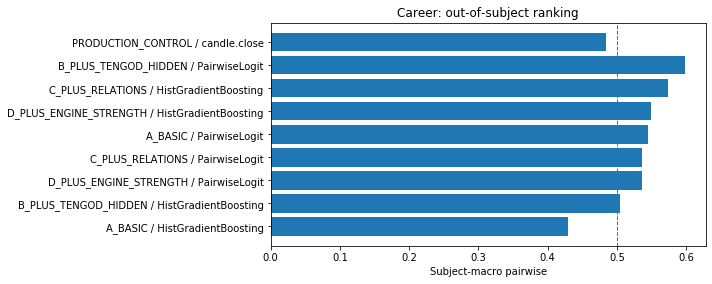

In [11]:
plot_df = result_with_control.dropna(subset=["macro_pairwise"]).copy()
plot_df["label"] = plot_df["feature_set"] + " / " + plot_df["model"]

fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.45)))
ax.barh(plot_df["label"], plot_df["macro_pairwise"])
ax.axvline(0.5, linestyle="--", linewidth=1)
ax.set_xlabel("Subject-macro pairwise")
ax.set_title(f"{TARGET_DOMAIN}: out-of-subject ranking")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 12. Decision rule for V1

Do **not** move to Cursor or collect 500 more people just because one run is slightly above Control.

Treat the ML path as promising only if all are true:

1. best Group-CV subject-macro pairwise is clearly above production Control
2. improvement is not driven by only one fold or a few subjects
3. adding `ten-god/hidden` or `relations` gives a repeatable improvement over raw pillars
4. no subject-name, event text, year identity, or future information is used as a feature
5. result survives a second deterministic seed / fold assignment

### If signal exists

Next notebook revision:

- add **strength**
- add **yongshin / heeshin / gishin activation**
- add **12-unseong**
- then test **shinsal / lucky stars last**

Each addition gets an ablation. Keep it only if out-of-subject CV improves.

### If signal does not exist

Do not tune dozens of coefficients. First improve the corpus, especially domain coverage and event labels.

## 13. Optional secondary target

Only after Career is understood, set:

```python
TARGET_DOMAIN = "Love"
```

and rerun.

Do not train Wealth, Health, or Family from V1 yet because their within-person positive/negative pair coverage is too sparse.